**Nombre del alumno:**  <br>
**Subcompetencia que cursa:**  <br><br>
**Instrucciones:** Este archivo es una plantilla para los ejercicios que requieran usar código.

# Práctica

In [ ]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm

Ejemplo prueba de bondad de ajuste de la Ji-cuadrada

A continuación se muestran los valores de la edad de 50 personas:

In [ ]:

data = """20  27  32  35  42
21  27  32  36  44
23  27  33  36  44
23  28  33  36  45
24  29  33  38  45
25  30  33  38  45
26  31  33  39  46
26  31  34  40  48
26  31  35  40  62
27  32  35  42  62"""

# Use io.StringIO to treat the string as a file
df = pd.read_csv(io.StringIO(data), sep='\s+', header=None)

df

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3s/s_cfgxk120b8xn2g6y1m9psw0000gn/T/ipykernel_34507/1062613912.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(data), sep='\s+', header=None)


,0,1,2,3,4
0,20,27,32,35,42
1,21,27,32,36,44
2,23,27,33,36,44
3,23,28,33,36,45
4,24,29,33,38,45
5,25,30,33,38,45
6,26,31,33,39,46
7,26,31,34,40,48
8,26,31,35,40,62
9,27,32,35,42,62


Se guardan todas las edades en un arreglo:

In [ ]:
edades = df.values.flatten().tolist()
edades

[20,
 27,
 32,
 35,
 42,
 21,
 27,
 32,
 36,
 44,
 23,
 27,
 33,
 36,
 44,
 23,
 28,
 33,
 36,
 45,
 24,
 29,
 33,
 38,
 45,
 25,
 30,
 33,
 38,
 45,
 26,
 31,
 33,
 39,
 46,
 26,
 31,
 34,
 40,
 48,
 26,
 31,
 35,
 40,
 62,
 27,
 32,
 35,
 42,
 62]

Se aplicará la prueba de bondad de ajuste de la Ji-cuadrada para determinar si los datos siguen o no una distribución normal.
El primer paso es construir una distribución de frecuencia de la muestra:


Clase 16-20: 1
Clase 21-25: 5
Clase 26-30: 10
Clase 31-35: 15
Clase 36-40: 8
Clase 41-45: 7
Clase 46-50: 2
Clase 51-55: 0
Clase 56-60: 0
Clase 61-65: 2


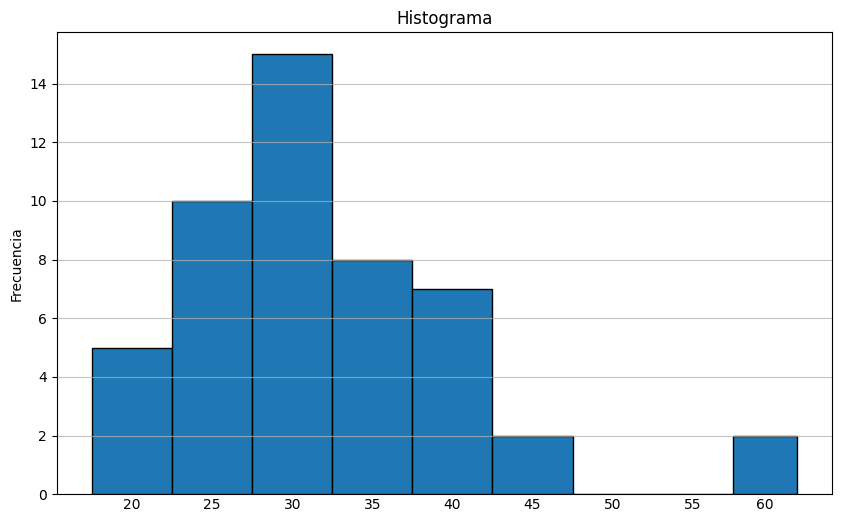

In [ ]:

class_ranges = [
    (16, 20),
    (21, 25),
    (26, 30),
    (31, 35),
    (36, 40),
    (41, 45),
    (46, 50),
    (51, 55),
    (56, 60),
    (61, 65)
]

# Initialize a dictionary to store the frequencies
class_frequencies = {f"{start}-{end}": 0 for start, end in class_ranges}

# Iterate through each number in the edades list
for edad in edades:
    # Check which class the number belongs to
    for (start, end) in class_ranges:
        if start <= edad <= end:
            class_frequencies[f"{start}-{end}"] += 1
            break

# Print the class frequencies
for class_range, frequency in class_frequencies.items():
    print(f"Clase {class_range}: {frequency}")

# Define the bins
bins = [21, 26, 31, 36, 41, 46, 51, 56, 61, 65]

# Bins have left and right edges, where all the right edges
# are exclusive except for the last one.

# e.g. first bin [21, 26), ..., last bin [61, 65]

bin_labels = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65]

# Create the histogram
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
n, bins, patches = plt.hist(edades, bins=bins, edgecolor='black', color='#1f78b4')  # Use a blue color

# Annotate each bar with its bin label
for i in range(len(patches)):
    x = patches[i].get_x() + patches[i].get_width() / 2  # Center x-coordinate
    y = -0.5
    plt.text(x, y, bin_labels[i], ha='center')  # Add the text

# Add labels and title
plt.title("Histograma")
plt.xticks([])
plt.ylabel("Frecuencia")

# Show the plot
plt.grid(axis='y', alpha=0.75) #add gridlines
plt.show()

El construir la distribución de frecuencia con datos discretos (sólo enteros) no considera que la normalidad es una distribución continua, por lo que la forma correcta de construir el histograma es la siguiente:

Clase 17.6-22.5: 2
Clase 22.6-27.5: 11
Clase 27.6-32.5: 9
Clase 32.6-37.5: 12
Clase 37.6-42.5: 7
Clase 42.6-47.5: 6
Clase 47.6-52.5: 1
Clase 52.6-57.5: 0
Clase 57.6-62.5: 2
Clase 62.6-67.5: 0


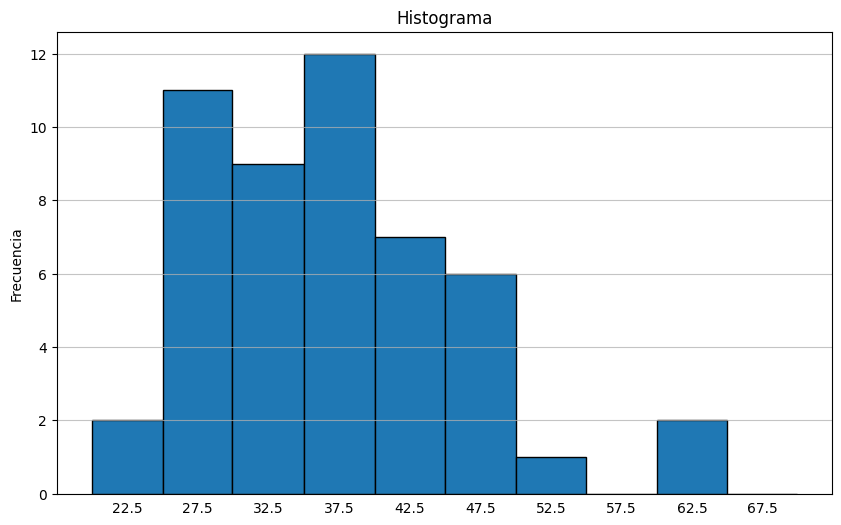

In [ ]:

class_ranges = [
    (17.6, 22.5),
    (22.6, 27.5),
    (27.6, 32.5),
    (32.6, 37.5),
    (37.6, 42.5),
    (42.6, 47.5),
    (47.6, 52.5),
    (52.6, 57.5),
    (57.6, 62.5),
    (62.6, 67.5)
]

# Initialize a dictionary to store the frequencies
class_frequencies = {f"{start}-{end}": 0 for start, end in class_ranges}

# Iterate through each number in the edades list
for edad in edades:
    # Check which class the number belongs to
    for (start, end) in class_ranges:
        if start <= edad <= end:
            class_frequencies[f"{start}-{end}"] += 1
            break

# Print the class frequencies
for class_range, frequency in class_frequencies.items():
    print(f"Clase {class_range}: {frequency}")

# Define the bins
bins = [17.6, 22.6, 27.5, 32.6, 37.6, 42.6, 47.6, 52.6, 57.6, 62.6, 67.5]

bin_labels = [22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5]

# Create the histogram
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
n, bins, patches = plt.hist(edades, bins=bins, edgecolor='black', color='#1f78b4')  # Use a blue color

# Annotate each bar with its bin label
for i in range(len(patches)):
    x = patches[i].get_x() + patches[i].get_width() / 2  # Center x-coordinate
    y = -0.5
    plt.text(x, y, bin_labels[i], ha='center')  # Add the text

# Add labels and title
plt.title("Histograma")
plt.xticks([])
plt.ylabel("Frecuencia")

# Show the plot
plt.grid(axis='y', alpha=0.75) #add gridlines
plt.show()

Es decir, partir la diferencia de 5 puntos entre 2, es decir 2.5, y darle la mitad a cada una de las clases.

Ahora, se utilizan los límites superiores de cada clase para el cálculo de la distribución acumulada de la distribución normal.
Para la aplicación de esta función, se debe calcular la media y la desviación estándar del conjunto de las 50 edades, que representan los parámetros de la distribución normal. Utilizando la biblioteca scipy, obtenemos los siguientes cálculos de las estadísticas descriptivas:


In [ ]:
# Calculate statistics
media = np.mean(edades)
error_tipico = stats.sem(edades)  # Standard Error of the Mean
mediana = np.median(edades)
moda = stats.mode(edades, keepdims=True)[0][0]  # Get the mode value
desviacion_estandar = np.std(edades, ddof=1)  # Sample standard deviation (ddof=1)
varianza_muestra = np.var(edades, ddof=1)  # Sample variance (ddof=1)
curtosis = stats.kurtosis(edades, fisher=True, bias=False)  # Fisher kurtosis
coeficiente_asimetria = stats.skew(edades, bias=False)  # Skewness
rango = np.ptp(edades)  # Range
minimo = np.min(edades)
maximo = np.max(edades)
suma = np.sum(edades)
cuenta = len(edades)

# Print the results
print("Edades")
print(f"Media: {media:.1f}")
print(f"Error típico: {error_tipico:.8f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Desviación estándar: {desviacion_estandar:.8f}")
print(f"Varianza de la muestra: {varianza_muestra:.8f}")
print(f"Curtosis: {curtosis:.8f}")
print(f"Coeficiente de asimetría: {coeficiente_asimetria:.8f}")
print(f"Rango: {rango}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Suma: {suma}")
print(f"Cuenta: {cuenta}")

Edades
Media: 34.6
Error típico: 1.28126213
Mediana: 33.0
Moda: 33
Desviación estándar: 9.05989143
Varianza de la muestra: 82.08163265
Curtosis: 1.62181743
Coeficiente de asimetría: 1.03196768
Rango: 42
Mínimo: 20
Máximo: 62
Suma: 1730
Cuenta: 50


Los valores de 34.6 y 9.05989143 (media y desviación estándar, respectivamente) serán los mismos para todas las clases:

In [ ]:

data = {
    'Limite sup de clases': [22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5],
    'Frecuencia': [2, 11, 9, 12, 7, 6, 1, 0, 2, 0]
}

# Create a Pandas DataFrame
df = pd.DataFrame(data)

mean = 34.6
std_dev = 9.05989143

cdf_approximations_a = []
for limit in df['Limite sup de clases']:
    z = (limit - mean) / std_dev
    cdf = norm.cdf(z)
    cdf_approximations_a.append(round(cdf, 8))

df['CDFA'] = cdf_approximations_a

df

,Limite sup de clases,Frecuencia,CDFA
0,22.5,2,0.090847
1,27.5,11,0.216616
2,32.5,9,0.408350
3,37.5,12,0.625551
4,42.5,7,0.808389
5,47.5,6,0.922756
6,52.5,1,0.975908
7,57.5,0,0.994258
8,62.5,2,0.998963
9,67.5,0,0.999859


Se puede observar que, al ser frecuencia acumulada, los valores de las probabilidades van aumentando hasta llegar a 1 en el valor máximo del conjunto de datos. El siguiente paso es calcular el valor de la probabilidad de cada clase:

In [ ]:

cdf_approximations_i = []
for i in range(1, len(df['Limite sup de clases'])):
    z1 = (df['Limite sup de clases'][i - 1] - mean) / std_dev
    z2 = (df['Limite sup de clases'][i] - mean) / std_dev
    cdf_diff = norm.cdf(z2) - norm.cdf(z1)
    cdf_approximations_i.append(round(cdf_diff, 9))

cdf_approximations_i.insert(0, round(norm.cdf((df['Limite sup de clases'][0]-mean)/std_dev), 9))


df['CDFI'] = cdf_approximations_i

df

,Limite sup de clases,Frecuencia,CDFA,CDFI
0,22.5,2,0.090847,0.090847
1,27.5,11,0.216616,0.125769
2,32.5,9,0.408350,0.191734
3,37.5,12,0.625551,0.217201
4,42.5,7,0.808389,0.182838
5,47.5,6,0.922756,0.114367
6,52.5,1,0.975908,0.053152
7,57.5,0,0.994258,0.018350
8,62.5,2,0.998963,0.004705
9,67.5,0,0.999859,0.000896


Suma de CDFI

In [ ]:
df['CDFI'].sum()

0.99985905

Se observa que la suma de probabilidades es 1, lo cual es lo esperado dado que debajo de la curva se incluyen todos los valores posibles desde el dato menor, hasta el dato mayor del conjunto de datos.
De la misma forma, serán distribuidos los 50 datos que representarán la frecuencia esperada o teórica bajo el supuesto de un comportamiento de distribución normal:


In [ ]:

total_count = 50  # Total number of data points
fe_values = []
for i in range(len(df['CDFI'])):
    fe = df['CDFI'][i] * total_count
    fe_values.append(round(fe, 8))


df['fe'] = fe_values

df

,Limite sup de clases,Frecuencia,CDFA,CDFI,fe
0,22.5,2,0.090847,0.090847,4.542354
1,27.5,11,0.216616,0.125769,6.288434
2,32.5,9,0.408350,0.191734,9.586724
3,37.5,12,0.625551,0.217201,10.860026
4,42.5,7,0.808389,0.182838,9.141914
5,47.5,6,0.922756,0.114367,5.718360
6,52.5,1,0.975908,0.053152,2.657586
7,57.5,0,0.994258,0.018350,0.917510
8,62.5,2,0.998963,0.004705,0.235257
9,67.5,0,0.999859,0.000896,0.044788


Uno de los requisitos de la distribución Ji-cuadrada es que todas las frecuencias esperadas deben ser mayores o iguales a 5, por lo que es necesario sumar las frecuencias esperadas hasta asegurar que esto se cumpla:

In [ ]:

# Calculate chi-fe
chi_fe_values = []
cumulative_fe = 0
for fe in df['fe']:
    cumulative_fe += fe
    if cumulative_fe >= 5:
        chi_fe_values += [cumulative_fe]
        cumulative_fe = 0
    else:
        chi_fe_values += ['']

# Add remaining to the last class.
for i in range(len(chi_fe_values) - 1, -1, -1):
    if isinstance(chi_fe_values[i], float):
        chi_fe_values[i] += cumulative_fe
        break

df['chi-fe'] = chi_fe_values

df

,Limite sup de clases,Frecuencia,CDFA,CDFI,fe,chi-fe
0,22.5,2,0.090847,0.090847,4.542354,
1,27.5,11,0.216616,0.125769,6.288434,10.830788
2,32.5,9,0.408350,0.191734,9.586724,9.586724
3,37.5,12,0.625551,0.217201,10.860026,10.860026
4,42.5,7,0.808389,0.182838,9.141914,9.141914
5,47.5,6,0.922756,0.114367,5.718360,9.573501
6,52.5,1,0.975908,0.053152,2.657586,
7,57.5,0,0.994258,0.018350,0.917510,
8,62.5,2,0.998963,0.004705,0.235257,
9,67.5,0,0.999859,0.000896,0.044788,


Suma de chi-fe

In [ ]:
def numberize(val):
    if val == '':
        return 0
    else:
        return val
df['chi-fe'].apply(numberize).sum()

49.992952499999994

De la misma forma que fueron agrupadas las clases de acuerdo a la frecuencia esperada, se realiza la suma con las frecuencias observadas:

In [ ]:

# Calculate chi-fo
chi_fo_values = []
cumulative_fo = 0
for fo, cfe in zip(df['Frecuencia'], chi_fe_values):
    cumulative_fo += fo
    if isinstance(cfe, float):
        chi_fo_values += [cumulative_fo]
        cumulative_fo = 0
    else:
        chi_fo_values += ['']

for i in range(len(chi_fo_values) - 1, -1, -1):
    if isinstance(chi_fo_values[i], int):
        chi_fo_values[i] += cumulative_fo
        break

df['chi-fo'] = chi_fo_values


df

,Limite sup de clases,Frecuencia,CDFA,CDFI,fe,chi-fe,chi-fo
0,22.5,2,0.090847,0.090847,4.542354,,
1,27.5,11,0.216616,0.125769,6.288434,10.830788,13
2,32.5,9,0.408350,0.191734,9.586724,9.586724,9
3,37.5,12,0.625551,0.217201,10.860026,10.860026,12
4,42.5,7,0.808389,0.182838,9.141914,9.141914,7
5,47.5,6,0.922756,0.114367,5.718360,9.573501,9
6,52.5,1,0.975908,0.053152,2.657586,,
7,57.5,0,0.994258,0.018350,0.917510,,
8,62.5,2,0.998963,0.004705,0.235257,,
9,67.5,0,0.999859,0.000896,0.044788,,


Ahora, se procede al cálculo de la Ji-cuadrada (X2):

In [ ]:

def calc_chi2(fields):
    fe, fo = fields
    if isinstance(fe, str) or isinstance(fo, str):
        return ''

    return ((fe - fo) ** 2) / fe
df['chi2'] = df[['chi-fe', 'chi-fo']].apply(calc_chi2,
                                            axis=1, )

df

,Limite sup de clases,Frecuencia,CDFA,CDFI,fe,chi-fe,chi-fo,chi2
0,22.5,2,0.090847,0.090847,4.542354,,,
1,27.5,11,0.216616,0.125769,6.288434,10.830788,13,0.434454
2,32.5,9,0.408350,0.191734,9.586724,9.586724,9,0.035908
3,37.5,12,0.625551,0.217201,10.860026,10.860026,12,0.119663
4,42.5,7,0.808389,0.182838,9.141914,9.141914,7,0.501842
5,47.5,6,0.922756,0.114367,5.718360,9.573501,9,0.034356
6,52.5,1,0.975908,0.053152,2.657586,,,
7,57.5,0,0.994258,0.018350,0.917510,,,
8,62.5,2,0.998963,0.004705,0.235257,,,
9,67.5,0,0.999859,0.000896,0.044788,,,


Suma de chi2, valor de Ji-cuadrada

In [ ]:
chi2_value = df['chi2'].apply(numberize).sum()
chi2_value

1.1262227640544238

Ahora, se procede al cálculo del valor p, tomando en cuenta que los grados de libertad resultantes serían: 5 clases – 2 parámetros desconocidos – 1, quedando como resultado 2 grados de libertad, y aplicando la función de chi cuadrada con scipy:

In [ ]:
1 - stats.chi2.cdf(chi2_value, 2)

0.5694345762197563

Recordemos que las hipótesis planteadas son:
H0: Las edades siguen una distribución normal.
H1: Las edades no siguen una distribución normal.

Dado que el p valor de 0.569 es mayor al alfa del 5%, no rechazamos H0, es decir, podemos concluir que las edades sí siguen una distribución normal.


# Respuesta correcta